### Task 1: MEAN ,MEDIAN AND MODE

In [122]:
import pandas as pd

In [123]:
df = pd.read_csv("Dataset/InternNova_Week4_Retail_Sales_Raw.csv")

In [124]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
0,ORD-1001,2026-08-01,CUST-116,33.0,Male,Notebook Pack,Stationery,North,1,600,0.0,600.0,214.35,Net Banking,3.4
1,ORD-1002,2026-08-02,CUST-115,51.0,Male,Mouse,Accessories,South,1,900,0.0,900.0,277.03,Net Banking,4.0
2,ORD-1003,2026-08-03,CUST-101,29.0,Female,Backpack,Accessories,East,4,2200,0.1,7920.0,1990.16,Debit Card,3.5
3,ORD-1004,2026-08-04,CUST-123,41.0,Female,Keyboard,Accessories,North,1,1800,0.0,1800.0,533.52,Cash,4.2
4,ORD-1005,2026-08-05,CUST-124,55.0,Male,Mouse,Accessories,North,1,900,0.1,810.0,244.52,UPI,4.4


In [125]:
df["Quantity"].head()

0    1
1    1
2    4
3    1
4    1
Name: Quantity, dtype: int64

In [126]:
df["Quantity"].mean()


np.float64(2.5483870967741935)

In [127]:
df["Quantity"].median()

np.float64(2.0)

In [128]:
df["Quantity"].mode()

0    1
Name: Quantity, dtype: int64

In [129]:
mean_quantity = df["Quantity"].mean()#The mean represents the average quantity of products purchased per order.
median_quantity = df["Quantity"].median()#The median represents the middle quantity value
mode_quantity = df["Quantity"].mode()[0] # HELP IN SHOWING MOST COMMON UNIT

print("Mean Quantity:", mean_quantity)
print("Median Quantity:", median_quantity)
print("Mode Quantity:", mode_quantity)

Mean Quantity: 2.5483870967741935
Median Quantity: 2.0
Mode Quantity: 1


The mean represents the average quantity of products purchased per order.

### Task 2: Variance & Standard Deviation

In [130]:
df["Quantity"].var()

np.float64(6.514013749338974)

In [131]:
df["Quantity"].std()

np.float64(2.552256599430977)

In [132]:
variance_quantity = df["Quantity"].var()
std_quantity = df["Quantity"].std()

print("Variance of Quantity:", variance_quantity)
print("Standard Deviation of Quantity:", std_quantity)

Variance of Quantity: 6.514013749338974
Standard Deviation of Quantity: 2.552256599430977


### Task 2 Explanation

Variance measures how much the quantity values are spread out from the mean.

Standard deviation shows the typical distance of the quantity values from the mean

### Task 3: Correlation & Probability Basics

In [133]:
df["Sales"].corr(df["Profit"])

np.float64(0.9970159726207426)

The correlation between Sales and Profit is approximately 0.997, indicating a very strong positive relationship. This means that higher sales are generally associated with higher profit in the dataset.

In [134]:
df["Category"].value_counts()

Category
Accessories    20
Electronics    18
Furniture      11
Stationery      6
Appliances      6
electronics     1
Name: count, dtype: int64

In [135]:
total_orders = len(df)
multi_item_orders = (df["Quantity"] > 1).sum()

probability = multi_item_orders / total_orders

print("Total Orders:", total_orders)
print("Orders with Quantity > 1:", multi_item_orders)
print("Probability:", probability)

Total Orders: 62
Orders with Quantity > 1: 42
Probability: 0.6774193548387096


TASK - 3 FINAL OUTPUT RESULT

In [136]:
correlation = df["Sales"].corr(df["Profit"])

total_orders = len(df)
multi_item_orders = (df["Quantity"] > 1).sum()
probability = multi_item_orders / total_orders

print("Correlation between Sales and Profit:", correlation)
print("Total Orders:", total_orders)
print("Orders with Quantity > 1:", multi_item_orders)
print("Probability:", probability)
print("Probability Percentage:", probability * 100, "%")

Correlation between Sales and Profit: 0.9970159726207426
Total Orders: 62
Orders with Quantity > 1: 42
Probability: 0.6774193548387096
Probability Percentage: 67.74193548387096 %


### Task 3 Explanation

**Correlation:**  
The correlation between Sales and Profit is approximately 0.997. This indicates a very strong positive correlation, meaning that higher sales are generally associated with higher profit in the dataset.

**Probability:**  
The probability of randomly selecting an order with a quantity greater than 1 is approximately 0.6774, or 67.74%. This means that about 67.74% of the orders contain more than one item.

### Task 4: Outlier Detection

In [137]:
Q1 = df["Quantity"].quantile(0.25)

print("Q1:", Q1)

Q1: 1.0


In [138]:
Q3 = df["Quantity"].quantile(0.75)

print("Q3:", Q3)

Q3: 3.0


In [139]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 2.0


In [140]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -2.0
Upper Bound: 6.0


In [141]:
outliers = df[
    (df["Quantity"] < lower_bound) |
    (df["Quantity"] > upper_bound)
]

outliers

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
17,ORD-1018,2026-08-18,CUST-101,23.0,Male,Laptop,Electronics,South,12,55000,0.05,627000.0,80665.56,UPI,4.8
44,ORD-1045,2026-09-14,CUST-114,51.0,Female,Monitor,Electronics,South,18,16000,0.20,230400.0,28167.22,UPI,3.7


TASK- 4 FINAL OUTPUT:

In [142]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Quantity"] < lower_bound) |
    (df["Quantity"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0


,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
17,ORD-1018,2026-08-18,CUST-101,23.0,Male,Laptop,Electronics,South,12,55000,0.05,627000.0,80665.56,UPI,4.8
44,ORD-1045,2026-09-14,CUST-114,51.0,Female,Monitor,Electronics,South,18,16000,0.20,230400.0,28167.22,UPI,3.7


### Task 4 Explanation

The IQR method was used to detect outliers in the Quantity column.

The calculated lower bound was -2.0 and the upper bound was 6.0. Two orders were identified as potential outliers because their quantities were greater than the upper bound.

The outlier quantities were 12 and 18 units.

Outliers can affect data analysis by increasing the mean, variance, and standard deviation and may give a misleading impression of typical customer purchasing behavior. However, outliers should be investigated before being removed because they may represent genuine high-value or bulk orders.

 Task 5: Matplotlib Visualization

In [143]:
import matplotlib.pyplot as plt

In [144]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [145]:
df_sorted = df.sort_values("Order_Date")

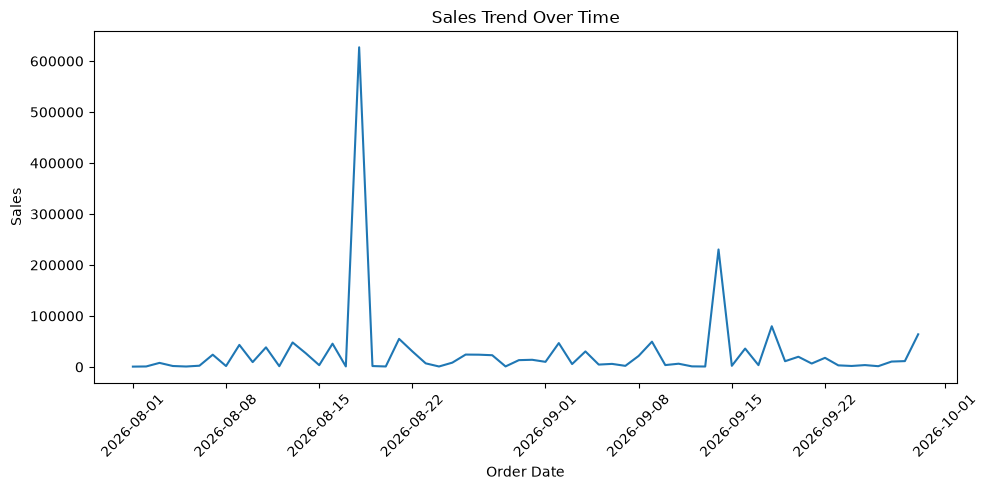

In [146]:
plt.figure(figsize=(10, 5))

plt.plot(df_sorted["Order_Date"], df_sorted["Sales"])

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Line Chart Explanation

The line chart shows how sales change over time based on the order dates. It helps identify fluctuations, increases, and decreases in sales across different dates.

In [147]:
product_sales = df.groupby("Product")["Sales"].sum()

product_sales

Product
Backpack          17490.0
Coffee Maker      47775.0
Desk              47175.0
Headphones         2375.0
Keyboard          19620.0
Laptop           778250.0
Monitor          517600.0
Mouse             10755.0
Notebook Pack      7470.0
Office Chair     122850.0
Printer          160200.0
Smartphone        79800.0
Name: Sales, dtype: float64

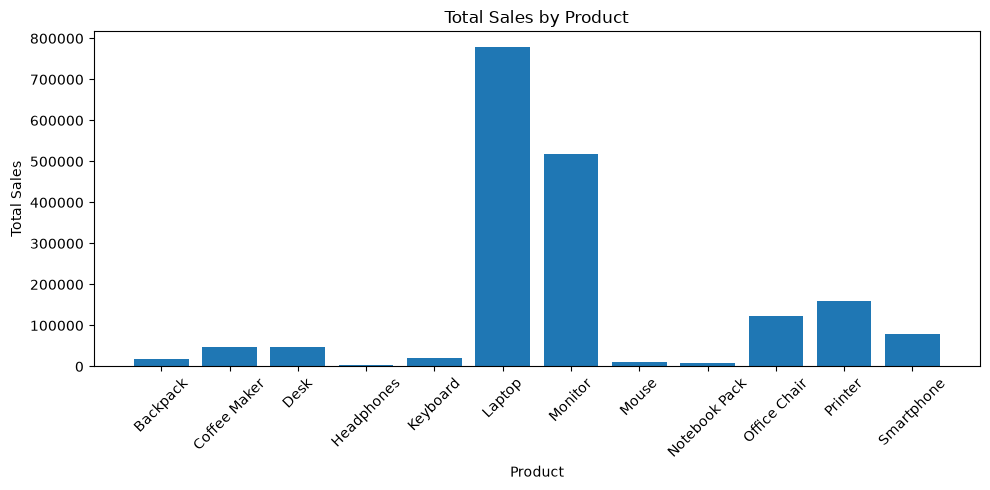

In [148]:
plt.figure(figsize=(10, 5))

plt.bar(product_sales.index, product_sales.values)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Bar Chart Explanation

The bar chart compares the total sales generated by each product. It helps identify which products contribute the most and least to overall sales.

In [149]:
gender_orders = df["Gender"].value_counts()

gender_orders

Gender
Male      33
Female    29
Name: count, dtype: int64

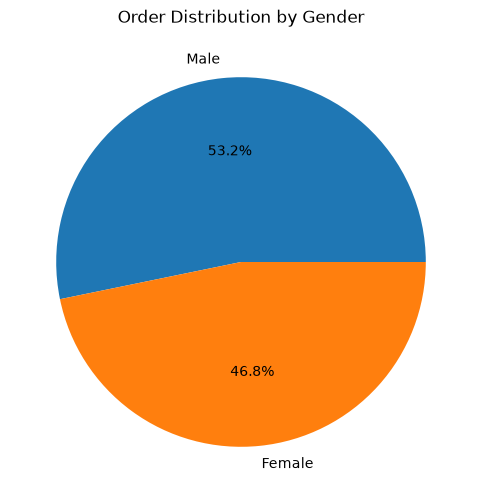

In [150]:
plt.figure(figsize=(6, 6))

plt.pie(
    gender_orders.values,
    labels=gender_orders.index,
    autopct="%1.1f%%"
)

plt.title("Order Distribution by Gender")

plt.show()

#### Pie Chart Explanation

The pie chart shows the proportion of orders by gender. It helps compare the percentage share of each gender category in the dataset.

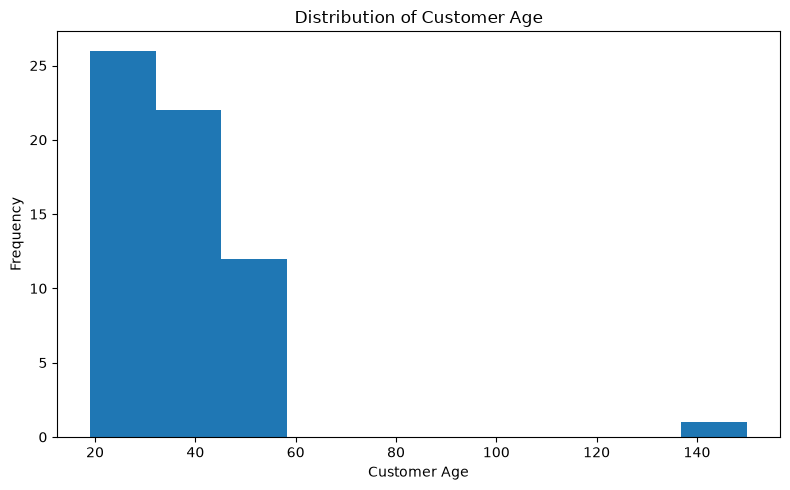

In [151]:
plt.figure(figsize=(8, 5))

plt.hist(df["Customer_Age"].dropna(), bins=10)

plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Histogram Explanation

The histogram shows the distribution of customer ages across different age ranges. It helps identify the most common age groups and also makes unusually high or low age values easier to notice.

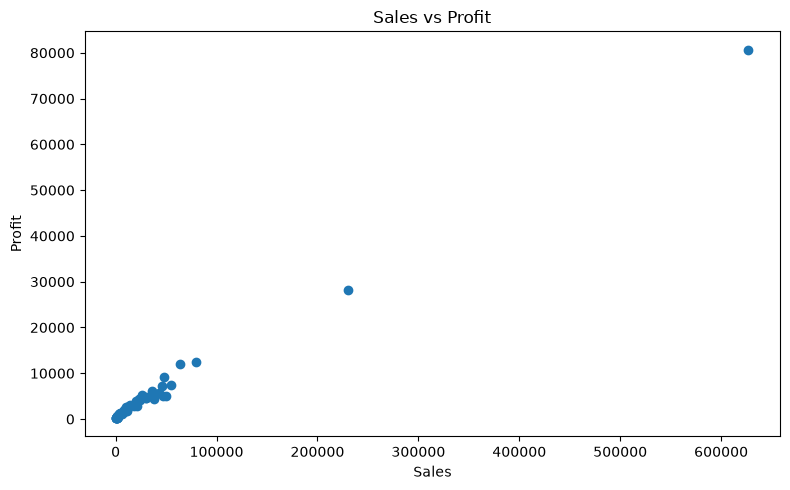

In [152]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

#### Scatter Plot Explanation

The scatter plot shows the relationship between Sales and Profit. The points generally move upward, indicating that higher sales are associated with higher profit.

 Task 6: Seaborn Visualization

In [153]:
import seaborn as sns

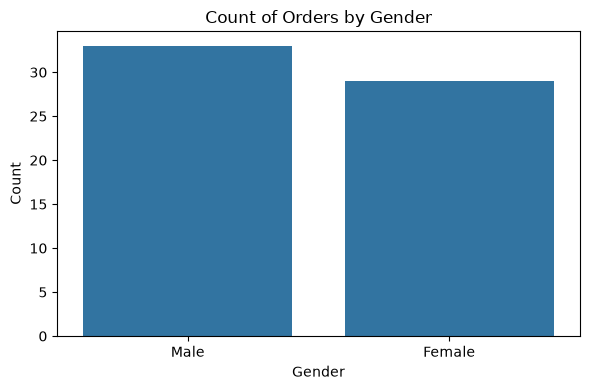

In [154]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Count of Orders by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Count Plot Explanation

The count plot shows the number of orders for each gender category. It helps compare the frequency of male and female customers in the dataset.

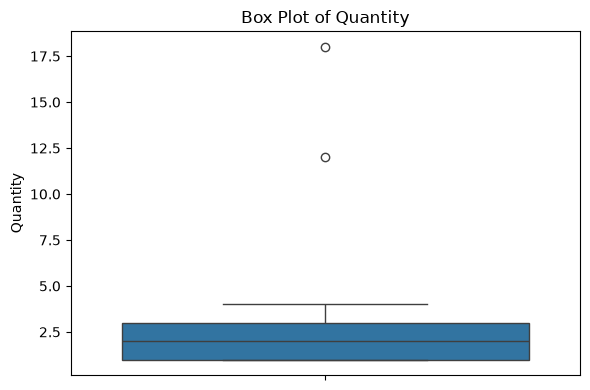

In [155]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, y="Quantity")

plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

#### Box Plot Explanation

The box plot shows the distribution of the Quantity column and helps identify potential outliers. Values that appear far beyond the whiskers may represent unusually large order quantities.

In [156]:
numeric_data = df.select_dtypes(include="number")

correlation_matrix = numeric_data.corr()

correlation_matrix

,Customer_Age,Quantity,Unit_Price,Discount,Sales,Profit,Rating
Customer_Age,1.000000,0.073663,-0.166313,0.045420,-0.060576,-0.050620,-0.180764
Quantity,0.073663,1.000000,0.230377,0.174221,0.723145,0.718568,-0.071228
Unit_Price,-0.166313,0.230377,1.000000,-0.086784,0.577811,0.570466,0.152541
Discount,0.045420,0.174221,-0.086784,1.000000,-0.018235,-0.054123,-0.195002
Sales,-0.060576,0.723145,0.577811,-0.018235,1.000000,0.997016,0.164146
Profit,-0.050620,0.718568,0.570466,-0.054123,0.997016,1.000000,0.171541
Rating,-0.180764,-0.071228,0.152541,-0.195002,0.164146,0.171541,1.000000


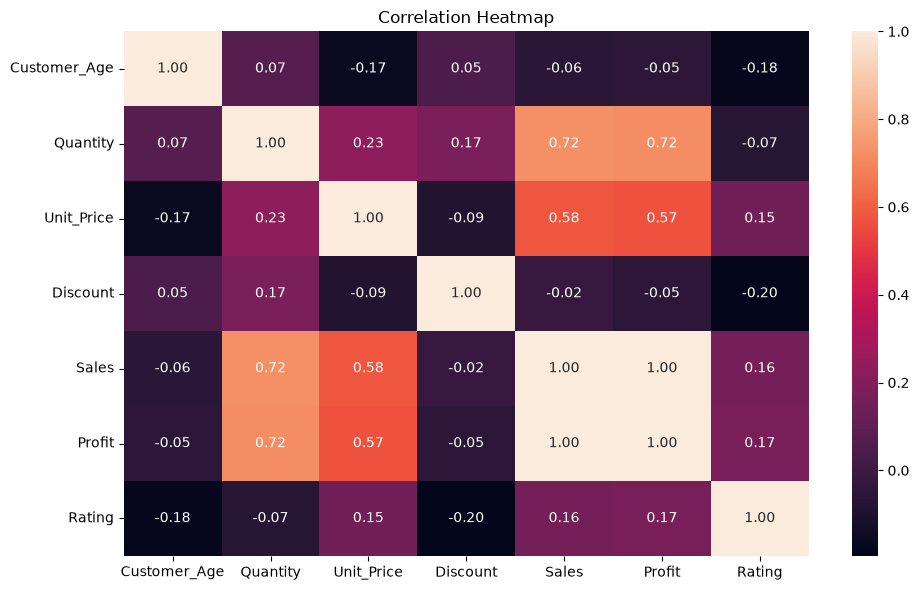

In [157]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

#### Heatmap Explanation

The heatmap shows the correlation between numerical variables in the dataset. Values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate a weak relationship.

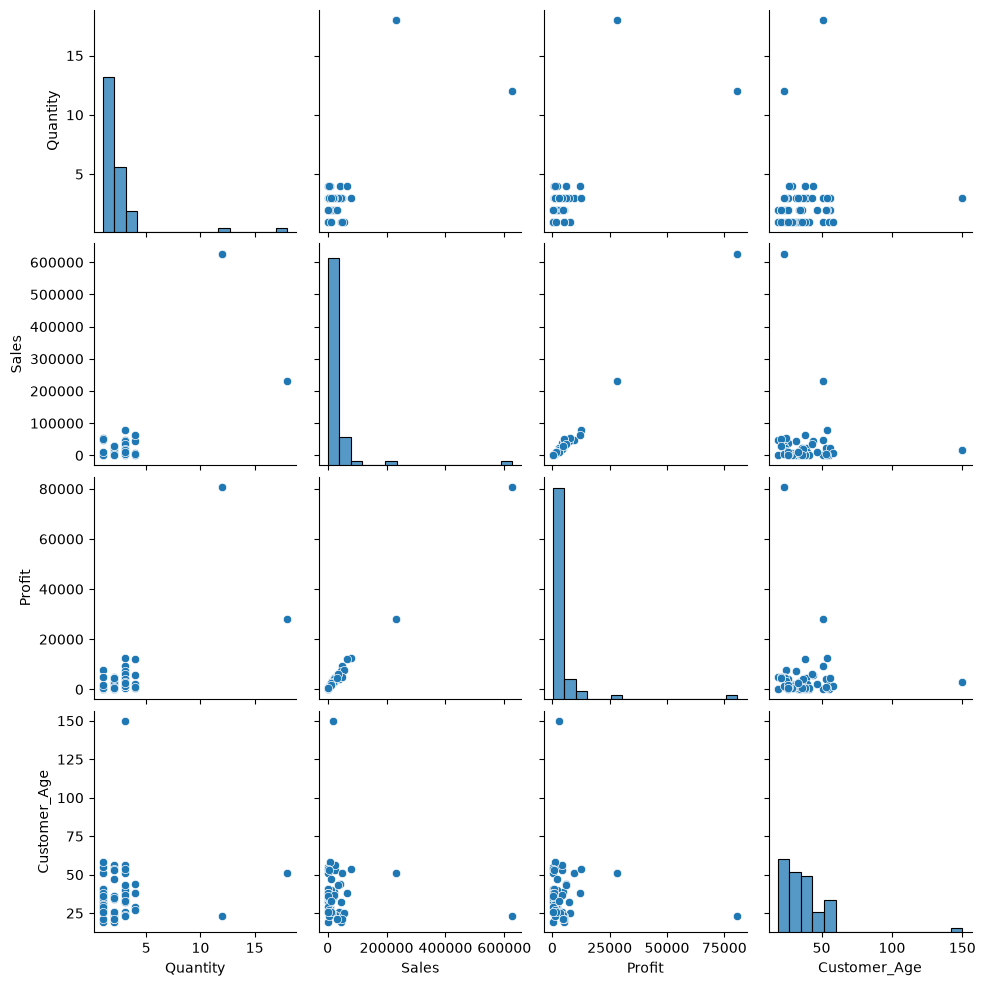

In [158]:
pairplot_data = df[["Quantity", "Sales", "Profit", "Customer_Age"]].dropna()

sns.pairplot(pairplot_data)

plt.show()

#### Pair Plot Explanation

The pair plot compares multiple numerical variables such as Quantity, Sales, Profit, and Customer Age. It helps identify relationships, trends, and distributions among these variables. A clear positive relationship can be observed between Sales and Profit.

### Task 7: Exploratory Data Analysis (EDA) – Data Inspection & Cleaning

In [159]:
df.shape

(62, 15)

In [160]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Age', 'Gender',
       'Product', 'Category', 'Region', 'Quantity', 'Unit_Price', 'Discount',
       'Sales', 'Profit', 'Payment_Method', 'Rating'],
      dtype='str')

In [161]:
df.dtypes

Order_ID                     str
Order_Date        datetime64[us]
Customer_ID                  str
Customer_Age             float64
Gender                       str
Product                      str
Category                     str
Region                       str
Quantity                   int64
Unit_Price                 int64
Discount                 float64
Sales                    float64
Profit                   float64
Payment_Method               str
Rating                   float64
dtype: object

In [162]:
df.describe()

,Order_Date,Customer_Age,Quantity,Unit_Price,Discount,Sales,Profit,Rating
count,62,61.000000,62.000000,62.000000,62.000000,62.000000,62.000000,60.000000
mean,2026-08-30 06:34:50.322580,37.311475,2.548387,9414.516129,0.079032,29215.483871,4361.360806,4.060000
min,2026-08-01 00:00:00,19.000000,1.000000,600.000000,0.000000,600.000000,214.350000,3.200000
25%,2026-08-15 06:00:00,26.000000,1.000000,1800.000000,0.012500,1925.000000,562.175000,3.700000
50%,2026-08-30 12:00:00,34.000000,2.000000,3500.000000,0.050000,8160.000000,1659.260000,4.100000
75%,2026-09-13 18:00:00,41.000000,3.000000,12000.000000,0.137500,26006.250000,4463.665000,4.425000
max,2026-09-29 00:00:00,150.000000,18.000000,55000.000000,0.200000,627000.000000,80665.560000,5.000000
std,NaN,18.251521,2.552257,13438.796867,0.068681,83837.119555,10730.138288,0.515588


In [163]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Age      1
Gender            0
Product           0
Category          0
Region            1
Quantity          0
Unit_Price        0
Discount          0
Sales             0
Profit            0
Payment_Method    0
Rating            2
dtype: int64

In [164]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Customer_Age    1
Region          1
Rating          2
dtype: int64

In [165]:
missing_values[missing_values > 0]

Customer_Age    1
Region          1
Rating          2
dtype: int64

In [166]:
df.duplicated().sum()

np.int64(2)

In [167]:
df[df.duplicated()]

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
60,ORD-1012,2026-08-12,CUST-101,26.0,Female,Mouse,Accessories,East,2,900,0.20,1440.0,381.42,UPI,3.7
61,ORD-1035,2026-09-04,CUST-124,21.0,Female,Monitor,Electronics,South,2,16000,0.05,30400.0,4628.55,Credit Card,4.4


In [168]:
print("Minimum Age:", df["Customer_Age"].min())
print("Maximum Age:", df["Customer_Age"].max())

Minimum Age: 19.0
Maximum Age: 150.0


In [169]:
print("Category Values:")
print(df["Category"].unique())

print("\nRegion Values:")
print(df["Region"].unique())

print("\nPayment Method Values:")
print(df["Payment_Method"].unique())

Category Values:
<StringArray>
[ 'Stationery', 'Accessories', 'Electronics',  'Appliances',   'Furniture',
 'electronics']
Length: 6, dtype: str

Region Values:
<StringArray>
['North', 'South', 'East', nan, 'West', 'north']
Length: 6, dtype: str

Payment Method Values:
<StringArray>
['Net Banking', 'Debit Card', 'Cash', 'UPI', 'Credit Card', 'upi']
Length: 6, dtype: str


In [170]:
df_before_cleaning = df.copy()

In [171]:
problem_rows = df[
    (df["Customer_Age"] > 100) |
    (df["Category"] == "electronics") |
    (df["Region"] == "north") |
    (df["Payment_Method"] == "upi") |
    (df.isnull().any(axis=1)) |
    (df.duplicated(keep=False))
]

problem_rows

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
6,ORD-1007,2026-08-07,CUST-111,53.0,Male,Printer,Electronics,NaN,2,12000,0.00,24000.0,4158.57,Cash,3.9
11,ORD-1012,2026-08-12,CUST-101,26.0,Female,Mouse,Accessories,East,2,900,0.20,1440.0,381.42,UPI,3.7
13,ORD-1014,2026-08-14,CUST-111,NaN,Male,Office Chair,Furniture,East,4,7000,0.05,26600.0,5202.57,Cash,3.2
20,ORD-1021,2026-08-21,CUST-122,25.0,Male,Laptop,electronics,South,1,55000,0.00,55000.0,7539.33,Credit Card,4.2
25,ORD-1026,2026-08-26,CUST-133,24.0,Male,Desk,Furniture,North,3,8500,0.05,24225.0,4426.06,Net Banking,NaN
31,ORD-1032,2026-09-01,CUST-114,40.0,Male,Coffee Maker,Appliances,north,3,3500,0.05,9975.0,2186.23,Net Banking,4.1
34,ORD-1035,2026-09-04,CUST-124,21.0,Female,Monitor,Electronics,South,2,16000,0.05,30400.0,4628.55,Credit Card,4.4
38,ORD-1039,2026-09-08,CUST-105,36.0,Female,Printer,Electronics,West,2,12000,0.10,21600.0,2923.73,upi,3.8
48,ORD-1049,2026-09-18,CUST-134,54.0,Female,Smartphone,Electronics,West,3,28000,0.05,79800.0,12372.39,Net Banking,NaN
52,ORD-1053,2026-09-22,CUST-127,150.0,Male,Office Chair,Furniture,West,3,7000,0.15,17850.0,2942.89,Cash,3.2


CLEANING

In [172]:
df.loc[df["Customer_Age"] > 100, "Customer_Age"] = pd.NA

In [173]:
median_age = df["Customer_Age"].median()

print("Median Age:", median_age)

Median Age: 34.0


In [174]:
df["Customer_Age"] = df["Customer_Age"].fillna(median_age)

In [175]:
df["Customer_Age"].isnull().sum()

np.int64(0)

In [177]:
region_mode = df["Region"].mode()[0]

print("Most Common Region:", region_mode)

Most Common Region: South


In [178]:
df["Region"] = df["Region"].fillna(region_mode)

In [180]:
df["Region"].isnull().sum()

np.int64(0)

In [181]:
median_rating = df["Rating"].median()

print("Median Rating:", median_rating)

Median Rating: 4.1


In [182]:
df["Rating"] = df["Rating"].fillna(median_rating)

In [184]:
df["Rating"].isnull().sum()

np.int64(0)

In [185]:
df = df.drop_duplicates()

In [186]:
df.shape

(60, 15)

In [187]:
df["Category"] = df["Category"].str.title()
df["Region"] = df["Region"].str.title()
df["Payment_Method"] = df["Payment_Method"].str.title()

In [188]:
df["Payment_Method"] = df["Payment_Method"].replace("Upi", "UPI")

In [189]:
print("Category Values:")
print(df["Category"].unique())

print("\nRegion Values:")
print(df["Region"].unique())

print("\nPayment Method Values:")
print(df["Payment_Method"].unique())

Category Values:
<StringArray>
['Stationery', 'Accessories', 'Electronics', 'Appliances', 'Furniture']
Length: 5, dtype: str

Region Values:
<StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str

Payment Method Values:
<StringArray>
['Net Banking', 'Debit Card', 'Cash', 'UPI', 'Credit Card']
Length: 5, dtype: str


In [190]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Rating
0,ORD-1001,2026-08-01,CUST-116,33.0,Male,Notebook Pack,Stationery,North,1,600,0.0,600.0,214.35,Net Banking,3.4
1,ORD-1002,2026-08-02,CUST-115,51.0,Male,Mouse,Accessories,South,1,900,0.0,900.0,277.03,Net Banking,4.0
2,ORD-1003,2026-08-03,CUST-101,29.0,Female,Backpack,Accessories,East,4,2200,0.1,7920.0,1990.16,Debit Card,3.5
3,ORD-1004,2026-08-04,CUST-123,41.0,Female,Keyboard,Accessories,North,1,1800,0.0,1800.0,533.52,Cash,4.2
4,ORD-1005,2026-08-05,CUST-124,55.0,Male,Mouse,Accessories,North,1,900,0.1,810.0,244.52,UPI,4.4


In [3]:
import pandas as pd

df = pd.read_csv("Dataset/InternNova_Week4_Retail_Sales_Cleaned.csv")

In [8]:
print("Dataset Shape:", df.shape)

print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nMinimum Age:", df["Customer_Age"].min())
print("Maximum Age:", df["Customer_Age"].max())

Dataset Shape: (60, 15)

Total Missing Values: 0
Duplicate Rows: 0

Minimum Age: 19.0
Maximum Age: 58.0


### Task 7 Explanation

The dataset was inspected to understand its structure, column names, data types, and statistical summary.

During data cleaning, missing values were identified in Customer_Age, Region, and Rating. Numerical missing values were handled using median values, while the missing Region was filled using the mode.

Two duplicate records were identified and removed.

An unrealistic Customer_Age value of 150 was treated as invalid and replaced using the median age.

Inconsistent text values such as `electronics`, `north`, and `upi` were standardized to `Electronics`, `North`, and `UPI`.

After cleaning, the dataset contained 60 rows and 15 columns, with no missing values or duplicate records.

In [9]:
df.to_csv("Dataset/InternNova_Week4_Retail_Sales_Cleaned.csv", index=False)

Task 8: EDA – Correlation & Insights

In [10]:
numeric_data = df.select_dtypes(include="number")

correlation_matrix = numeric_data.corr()

correlation_matrix

,Customer_Age,Quantity,Unit_Price,Discount,Sales,Profit,Rating
Customer_Age,1.000000,0.083170,-0.251916,-0.091811,-0.084207,-0.068636,0.020718
Quantity,0.083170,1.000000,0.231254,0.184304,0.723218,0.718696,-0.071504
Unit_Price,-0.251916,0.231254,1.000000,-0.067237,0.577818,0.570059,0.140849
Discount,-0.091811,0.184304,-0.067237,1.000000,-0.008702,-0.044386,-0.176472
Sales,-0.084207,0.723218,0.577818,-0.008702,1.000000,0.997024,0.161720
Profit,-0.068636,0.718696,0.570059,-0.044386,0.997024,1.000000,0.168606
Rating,0.020718,-0.071504,0.140849,-0.176472,0.161720,0.168606,1.000000


In [11]:
sales_correlations = correlation_matrix["Sales"].sort_values(ascending=False)

sales_correlations

Sales           1.000000
Profit          0.997024
Quantity        0.723218
Unit_Price      0.577818
Rating          0.161720
Discount       -0.008702
Customer_Age   -0.084207
Name: Sales, dtype: float64

In [12]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Analysis of Numerical Variables")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Task 8 Insights

1. **Sales and Profit have a very strong positive correlation of approximately 0.997.** This indicates that orders with higher sales generally generate higher profit.

2. **Sales and Quantity have a strong positive correlation of approximately 0.723.** This suggests that larger order quantities generally contribute to higher sales.

3. **Sales and Unit Price have a moderate positive correlation of approximately 0.578.** Higher-priced products tend to contribute more to sales revenue.

4. **Discount has almost no linear correlation with Sales (-0.009).** In this dataset, increasing discounts does not appear to have a meaningful direct relationship with overall sales.

5. **Customer Age has a very weak negative correlation with Sales (-0.084).** This suggests that customer age is not an important factor in determining sales in this dataset.

Task 9: Business Recommendations

#### Recommendation 1: Encourage Larger Order Quantities

The business should encourage customers to purchase more units through product bundles, combo offers, or quantity-based promotions.

This recommendation is supported by the strong positive correlation of approximately 0.723 between Quantity and Sales. The result indicates that orders with higher quantities are generally associated with higher sales.

#### Recommendation 2: Do Not Depend Heavily on Discounts to Increase Sales

The business should avoid using discounts as the main strategy for increasing sales and should evaluate discount campaigns carefully before applying them.

This recommendation is supported by the correlation of approximately -0.009 between Discount and Sales. This value is very close to zero, which indicates that discounts have almost no linear relationship with sales in this dataset.